# 5.0 Cosmos Reason 2 — End-to-end VLM Compression

In this notebook you will run the **complete compression pipeline** — prune → distill → quantize → serve → evaluate — on NVIDIA's [`nvidia/Cosmos-Reason2-2B`](https://huggingface.co/nvidia/Cosmos-Reason2-2B), a reasoning-specialised Vision-Language Model.

Notebooks [01](01_pruning_vlm.ipynb), [02](02_distillation_vlm.ipynb), [03](03_quantization_vlm.ipynb), [04](04_serving_and_eval_vlm.ipynb) walk through each stage individually on Qwen3-VL-8B-Instruct. **This notebook condenses all of them into one end-to-end run on a different model and shows quality recovery.** The Megatron-Bridge wrappers transfer across VLM families without code changes.

**Recovery target.** The compressed checkpoint at the end (pruned LM 1.4 B + distilled + FP8 — full VLM ~1.7 B) should land within a couple of points of the BF16 baseline on MathVista and on Cosmos's own Physical AI Bench domain, while not regressing on a general benchmark (RealWorldQA). §6 sets up a 4-way comparison so you can read off `% recovered` for each benchmark. The 15 % cut is on the LM tower (1.7 B → 1.4 B); the vision encoder + projector (0.3 B) is untouched, so the full VLM goes 2.0 B → ~1.7 B. The cut is intentionally conservative — the goal here is *full* recovery; aggressive compression (1.0–1.2 B LM) is a follow-on.

Pipeline overview (numbers assume **1 node, 8×H100**):

| Stage | What it does | Wall-time (approx.) |
|---|---|---|
| §1 Download | Pull the gated HF checkpoint (Cosmos-Reason2-2B, ~5 GB; LM tower 1.7 B + vision 0.3 B) | 5 min |
| §2 Prune (NAS) | Minitron NAS on the LM tower, target 1.4 B (15 % cut) | 15-25 min |
| §3 Distill | Text-only KD on the pruned LM tower, ~5 k iters | 8-14 h |
| §4 Quantize | FP8 PTQ with image-aware calibration | 10-15 min |
| §5 Serve | vLLM OpenAI-compatible endpoint | <2 min to spin up |
| §6 Evaluate | 4-way comparison × MathVista / PAI-Bench / RealWorldQA | 2-3 h |

> 🔐 Cosmos Reason 2 is **gated** on HuggingFace. Before running §1 request access at the model page and authenticate: `hf auth login --token <YOUR_HF_TOKEN>`.

> 🖥️ §3 (distillation) is the only stage that needs the full 8-GPU node. §2/§4/§5 each run on 1×H100; §6 reuses one GPU for the vLLM endpoint.

---
## 5.1 Download Cosmos Reason 2 and Inspect the Architecture

Pull the checkpoint locally and read its `config.json`. Then we inspect the architecture of the model.

In [9]:
COSMOS_PATH = "/workspace/user_homes/lmikaelyan/Cosmos-Reason2-2B"

!hf download nvidia/Cosmos-Reason2-2B --local-dir {COSMOS_PATH}
!ls {COSMOS_PATH} | head

Fetching 15 files: 100%|███████████████████████| 15/15 [00:00<00:00, 535.84it/s]
Download complete: : 0.00B [00:00, ?B/s]              /workspace/user_homes/lmikaelyan/Cosmos-Reason2-2B
Download complete: : 0.00B [00:00, ?B/s]
CR2 Performance by Category.png
PAI_Bench_Leaderboard.png
README.md
chat_template.json
config.json
cosmos_cr2_2b_paiBench.png
generation_config.json
merges.txt
model.safetensors
preprocessor_config.json


/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/workspace/user_homes/lmikaelyan/Model-Optimizer/modelopt/torch/__init__.py:55: UserWarning: transformers>=5.0 support is experimental. Unified Hugging Face checkpoint export for quantized checkpoints may not work for some models yet.
  _warnings.warn(
Loading weights: 100%|██████████| 626/626 [00:07<00:00, 78.41it/s] 
The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Total VLM params:               2.44 B
  Language tower (model.language_model):  1.72 B
  Vision + projector + heads:   0.72 B

architectures:           ['Qwen3VLForConditionalGeneration']
text_config.model_type:  qwen3_vl_text
num_hidden_layers:       28
hidden_size:             2048
num_attention_heads:     16
num_key_value_heads:     8
intermediate_size:       6144


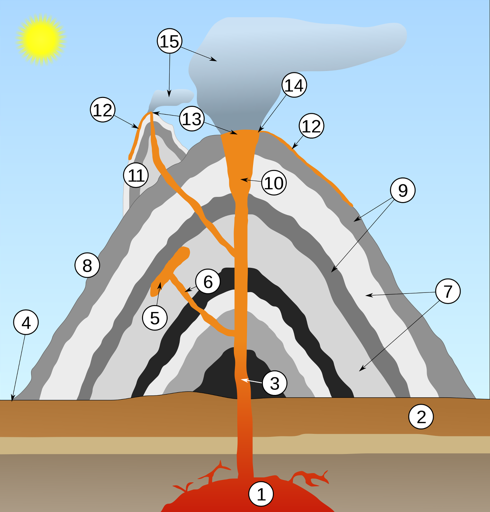

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Baseline caption: A detailed diagram of a volcano, showcasing its internal structure and external features, including magma movement, volcanic activity, and surrounding geological layers.


In [10]:
# Inspect the architecture of Cosmos Reason 2 and run a baseline caption.
from transformers import AutoConfig, AutoModelForImageTextToText, AutoProcessor
from modelopt.torch.utils.plugins.vlm import (
    VLM_TEXT_TO_CAUSAL_MODEL_TYPE, _vlm_text_to_causal_model_type,
    is_vlm_checkpoint, resolve_vlm_lm_path,
)
from IPython.display import display
from PIL import Image
import requests, torch

cfg = AutoConfig.from_pretrained(COSMOS_PATH, trust_remote_code=True)
tc  = cfg.text_config

vlm = AutoModelForImageTextToText.from_pretrained(
    COSMOS_PATH, dtype=torch.bfloat16, device_map="auto", trust_remote_code=True
)
processor = AutoProcessor.from_pretrained(COSMOS_PATH, trust_remote_code=True)

# resolve_vlm_lm_path returns a dotted path like "model.language_model" — the same one
# the prune/distill scripts use to extract / reinsert the LM tower.
lm_path = resolve_vlm_lm_path(vlm)
lm = vlm
for part in lm_path.split("."):
    lm = getattr(lm, part)

total_b = sum(p.numel() for p in vlm.parameters()) / 1e9
lm_b    = sum(p.numel() for p in lm.parameters()) / 1e9
print(f"Total VLM params:               {total_b:.2f} B")
print(f"  Language tower ({lm_path}):  {lm_b:.2f} B")
print(f"  Vision + projector + heads:   {total_b - lm_b:.2f} B")
print()
print(f"architectures:           {cfg.architectures}")
print(f"text_config.model_type:  {tc.model_type}")
print(f"num_hidden_layers:       {tc.num_hidden_layers}")
print(f"hidden_size:             {tc.hidden_size}")
print(f"num_attention_heads:     {tc.num_attention_heads}")
print(f"num_key_value_heads:     {tc.num_key_value_heads}")
print(f"intermediate_size:       {tc.intermediate_size}")

# Baseline caption — same image/prompt as the post-prune check in §5.2 so you can
# eyeball the two captions side by side.
url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/ai2d-demo.jpg"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
preview = image.copy(); preview.thumbnail((512, 512)); display(preview)

messages = [{"role": "user", "content": [
    {"type": "image", "image": image},
    {"type": "text", "text": "Describe the image in one short sentence."},
]}]
inputs = processor.apply_chat_template(
    messages, add_generation_prompt=True, tokenize=True, return_dict=True, return_tensors="pt"
).to(vlm.device)
out = vlm.generate(**inputs, max_new_tokens=64, do_sample=False)
print("Baseline caption:", processor.batch_decode(out[:, inputs['input_ids'].shape[1]:], skip_special_tokens=True)[0])

In [11]:
# Empty the memory to proceed
import gc; del vlm; gc.collect(); torch.cuda.empty_cache()

---
## 5.2 Prune via Neural Architecture Search

We use the same [`prune_minitron.py`](../prune_minitron.py) script as notebook 01, but with a **NAS target** (`--prune_target_params 1.4e9`) instead of `--prune_export_config`. NAS enumerates candidate shapes by varying number of layers, attention heads, KV groups and FFN hidden size; ranks them against the size budget; scores the top-K on a lightweight benchmark; and exports the highest-scoring shape. For a reasoning model with non-obvious quality/size trade-offs that's the right default.

> ⚠️ `--hparams_to_skip hidden_size` is **mandatory** here. Without it NAS will happily pick a smaller `hidden_size` to hit the budget, and the reinsertion step will refuse to splice the smaller LM back into the original vision projector (`ValueError` in `reinsert_pruned_lm_into_vlm`). If you intentionally want a smaller hidden_size, drop the flag and plan on retraining the projector separately.

The Cosmos Reason 2 LM tower is ~1.7 B parameters (the remaining ~0.3 B in the 2 B VLM is the vision encoder + projector, which the prune script does not touch). Targeting 1.4 B is a **15 % cut on the LM tower** — i.e. the full VLM shrinks 2.0 B → ~1.7 B. Small enough that distillation (§3) should fully recover quality on a single 24 h node. Push the LM target to 1.2 B / 1.0 B in a follow-up once the 15 % recipe is dialled in.

In [4]:
PRUNED_PATH = "/workspace/user_homes/lmikaelyan/Cosmos-Reason2-pruned-NAS-1.5B"

!torchrun --nproc_per_node 1 ../prune_minitron.py \
    --pp_size 1 \
    --hf_model_name_or_path {COSMOS_PATH} \
    --prune_target_params 1.51e9 \
    --hparams_to_skip hidden_size \
    --top_k 20 \
    --calib_dataset_name wikitext \
    --calib_num_samples 512 \
    --output_hf_path {PRUNED_PATH}

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
Traceback (most recent call last):
  File "/workspace/user_homes/lmikaelyan/Model-Optimizer/examples/megatron_bridge/notebooks/../prune_minitron.py", line 47, in <module>
W0519 10:05:26.760000 7706 torch/distributed/elastic/agent/server/api.py:739] Received 2 death signal, shutting down workers
    from megatron.bridge import AutoBridge
  File "/opt/Megatron-Bridg

In [8]:
PRUNED_PATH = "/workspace/user_homes/lmikaelyan/Cosmos-Reason2-pruned-depth-24"
COSMOS_PATH = "/workspace/user_homes/lmikaelyan/Cosmos-Reason2-2B"

!torchrun --nproc_per_node 1 ../prune_minitron.py \
    --pp_size 1 \
    --hf_model_name_or_path {COSMOS_PATH} \
    --prune_export_config '{{"num_layers": 24}}' \
    --calib_dataset_name wikitext \
    --calib_num_samples 512 \
    --output_hf_path {PRUNED_PATH}

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (64)/workspace/user_homes/lmikaelyan/Model-Optimizer/modelopt/torch/__init__.py:55: UserWarning: transformers>=5.0 support is experimental. Unified Hugging Face checkpoint export for quantized checkpoints may not work for some models yet.
  _warnings.warn(
/opt/Megatron-Bridge/3rdpar

Loading weights:   0%|          | 0/603 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 603/603 [00:04<00:00, 142.67it/s]


Total VLM params:              2.03 B
  Language tower (model.language_model): 1.62 B  (pruned)
  Vision + projector + heads:  0.41 B  (unchanged)

num_hidden_layers:   26  (NAS picked)
num_attention_heads: 16  (NAS picked)
num_key_value_heads: 8  (NAS picked)
intermediate_size:   6144  (NAS picked)
hidden_size:         2048  # locked at original


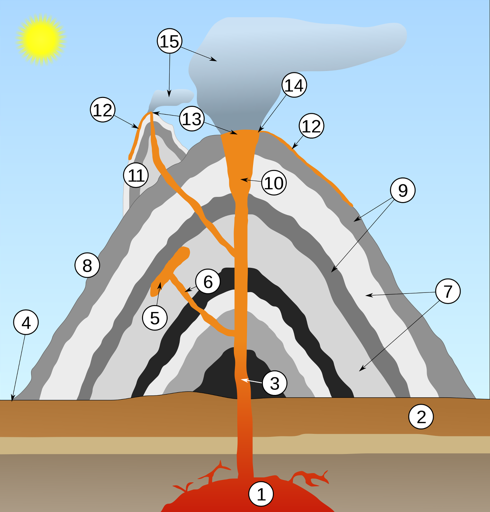

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


Caption: An illustration of a volcano with various numbered elements illustrating different processes and structures within the volcano and its surroundings, under a clear blue daytime scene with a visible sun.


In [12]:
# Verify NAS-selected shape, confirm hidden_size is locked, and check the VLM still captions.
from transformers import AutoModelForImageTextToText, AutoProcessor
from modelopt.torch.utils.plugins.vlm import resolve_vlm_lm_path
from IPython.display import display
from PIL import Image
import requests, torch

pruned = AutoModelForImageTextToText.from_pretrained(
    PRUNED_PATH, dtype=torch.bfloat16, device_map="auto", trust_remote_code=True
)
processor = AutoProcessor.from_pretrained(PRUNED_PATH, trust_remote_code=True)
tc = pruned.config.text_config

lm_path = resolve_vlm_lm_path(pruned)
lm = pruned
for part in lm_path.split("."):
    lm = getattr(lm, part)
total_b = sum(p.numel() for p in pruned.parameters()) / 1e9
lm_b    = sum(p.numel() for p in lm.parameters()) / 1e9

print(f"Total VLM params:              {total_b:.2f} B")
print(f"  Language tower ({lm_path}): {lm_b:.2f} B  (pruned)")
print(f"  Vision + projector + heads:  {total_b - lm_b:.2f} B  (unchanged)")
print()
print(f"num_hidden_layers:   {tc.num_hidden_layers}  (NAS picked)")
print(f"num_attention_heads: {tc.num_attention_heads}  (NAS picked)")
print(f"num_key_value_heads: {tc.num_key_value_heads}  (NAS picked)")
print(f"intermediate_size:   {tc.intermediate_size}  (NAS picked)")
print(f"hidden_size:         {tc.hidden_size}  # locked at original")

url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/ai2d-demo.jpg"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
preview = image.copy(); preview.thumbnail((512, 512)); display(preview)

messages = [{"role": "user", "content": [
    {"type": "image", "image": image},
    {"type": "text", "text": "Describe the image in one short sentence."},
]}]
inputs = processor.apply_chat_template(
    messages, add_generation_prompt=True, tokenize=True, return_dict=True, return_tensors="pt"
).to(pruned.device)
out = pruned.generate(**inputs, max_new_tokens=64, do_sample=False)
print("Caption:", processor.batch_decode(out[:, inputs['input_ids'].shape[1]:], skip_special_tokens=True)[0])

import gc; del pruned; gc.collect(); torch.cuda.empty_cache()

---
## 5.3 Knowledge Distillation

Text-only knowledge distillation from the unpruned Cosmos Reason 2 (teacher) into the pruned VLM (student), via [`distill.py`](../distill.py). The wrapper extracts both LM towers, runs `kd_loss` distillation on text tokens, then reinserts the distilled student LM back into the original VLM container.

**Cosmos Reason 2 is a reasoning VLM**, so the distillation corpus should preserve reasoning. We blend three Nemotron sources at sampling weights `0.5 / 0.3 / 0.2`:

| Dataset (HF) | Subset | Weight | Why |
|---|---|---:|---|
| `nvidia/Nemotron-Pretraining-Dataset-sample` | `Nemotron-CC-High-Quality-Synthetic` | 0.5 | General high-quality synthetic text — keeps the base language capability healthy. |
| `nvidia/Nemotron-Pretraining-SFT-v1` | `Nemotron-SFT-Math` | 0.3 | Chain-of-thought math reasoning. |
| `nvidia/Nemotron-Pretraining-SFT-v1` | `Nemotron-SFT-Code` | 0.2 | Chain-of-thought code reasoning. |

Tokenise each separately so they end up as **three distinct `.bin`/`.idx` prefixes**, then pass them to `distill.py` via `--data_paths <w> <prefix> <w> <prefix> <w> <prefix>`. All three are pretraining-style raw-text corpora (`text` key) → use `--append_eod`. See [`../dataset/MEGATRON_DATA_PREP.md`](../../dataset/MEGATRON_DATA_PREP.md) for chat-formatted alternatives.

In [13]:
import os, json
from itertools import islice
from datasets import load_dataset

RAW_DIR       = "/workspace/user_homes/lmikaelyan/distill_data_cosmos/raw"
TOKENIZED_DIR = "/workspace/user_homes/lmikaelyan/distill_data_cosmos/tokenized_cosmos"
os.makedirs(RAW_DIR, exist_ok=True)

# Streaming mode pulls parquet shards on demand, so disk usage tracks MAX_SAMPLES, not
# the source size. At gbs=512, seq=4096, 5 k iters consume ~10 B tokens; with 3 shards
# averaging ~500-1000 tokens/doc the 2 M-per-shard cap below leaves enough variety
# that the schedule does not loop. Drop back to 200_000 for a smoke run.
MAX_SAMPLES = 2_000_000

# Each tuple: (hf_dataset, hf_subset, output_jsonl_stem, sampling_weight).
SOURCES = [
    ("nvidia/Nemotron-Pretraining-Dataset-sample", "Nemotron-CC-High-Quality-Synthetic", "nemotron_cc",  0.5),
    ("nvidia/Nemotron-Pretraining-SFT-v1",         "Nemotron-SFT-MATH",                  "nemotron_math", 0.3),
    ("nvidia/Nemotron-Pretraining-SFT-v1",         "Nemotron-SFT-Code",                  "nemotron_code", 0.2),
]

for hf, subset, stem, _ in SOURCES:
    jsonl_path = f"{RAW_DIR}/{stem}.jsonl"
    if os.path.exists(jsonl_path) and os.path.getsize(jsonl_path) > 0:
        print(f"  {stem:<14} (cached) → {jsonl_path}")
        continue
    print(f"  {stem:<14} streaming up to {MAX_SAMPLES:,} docs from {hf}::{subset}...")
    ds = load_dataset(hf, subset, split="train", streaming=True)
    n = 0
    with open(jsonl_path, "w") as f:
        for row in islice(ds, MAX_SAMPLES):
            text = row.get("text", "")
            if not text or not text.strip():
                continue
            f.write(json.dumps({"text": text}) + "\n")
            n += 1
            if n % 10_000 == 0:
                print(f"    ... wrote {n:,}")
    print(f"  {stem:<14} {n:>7} docs → {jsonl_path}")

  nemotron_cc    (cached) → /workspace/user_homes/lmikaelyan/distill_data_cosmos/raw/nemotron_cc.jsonl
  nemotron_math  (cached) → /workspace/user_homes/lmikaelyan/distill_data_cosmos/raw/nemotron_math.jsonl
  nemotron_code  (cached) → /workspace/user_homes/lmikaelyan/distill_data_cosmos/raw/nemotron_code.jsonl


In [ ]:
# Tokenise all three JSONLs in one shot. megatron_preprocess_data with multiple
# --jsonl_paths produces one .bin/.idx per input, so we get three separately-weightable
# prefixes that we'll plumb into distill.py below.
PRUNED_PATH = "/workspace/user_homes/lmikaelyan/Cosmos-Reason2-pruned-NAS-1.5B"
TOKENIZED_DIR = "/workspace/user_homes/lmikaelyan/distill_data_cosmos/tokenized_cosmos-2"

!python -m modelopt.torch.utils.plugins.megatron_preprocess_data \
    --jsonl_paths \
        /workspace/user_homes/lmikaelyan/distill_data_cosmos/raw/nemotron_cc.jsonl \
        /workspace/user_homes/lmikaelyan/distill_data_cosmos/raw/nemotron_math.jsonl \
        /workspace/user_homes/lmikaelyan/distill_data_cosmos/raw/nemotron_code.jsonl \
    --json_keys text \
    --tokenizer {PRUNED_PATH} \
    --output_dir {TOKENIZED_DIR} \
    --workers 8 \
    --append_eod

!ls {TOKENIZED_DIR}

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (64)/opt/venv/lib/python3.12/site-packages/comet_ml/error_tracking/api.py:51: UserWarning: We won't be continuing development on SDK 3.0. Please use the last stable version of the SDK to get access to the newest features and fixes. See https://github.com/getsentry/sentry-python/discussions/4955
  sentry_sdk.init(
/workspace/user_homes/lmikaelyan/Model-Optimizer/modelopt/torch/__init__.py:55: UserWarning: transformers>=5.0 support is experimental. Unified Hugging Face checkpoint export for quantized checkpoints may not work for some models yet.
  _warnings.warn(
<frozen runpy>:128: RuntimeWarnin

In [14]:
PRUNED_PATH = "/workspace/user_homes/lmikaelyan/Cosmos-Reason2-pruned-depth"
TOKENIZED_DIR = "/workspace/user_homes/lmikaelyan/distill_data_cosmos/tokenized_cosmos-2"
DISTILL_WORK_DIR = "/workspace/user_homes/lmikaelyan/Cosmos-Reason2-pruned-depth-distill1"

In [15]:
DISTILLED_PATH = "/workspace/user_homes/lmikaelyan/Cosmos-Reason2-distilled1"
# Sampling weights from §5.3 — must sum to 1.0; distill.py mixes them per training step.
DATA_PATHS = (
    f"0.1 {TOKENIZED_DIR}/nemotron_cc_text "
    f"0.6 {TOKENIZED_DIR}/nemotron_math_text "
    f"0.5 {TOKENIZED_DIR}/nemotron_code_text"
)

!torchrun --nproc_per_node 4 ../distill.py \
    --tp_size 1 \
    --student_hf_path {PRUNED_PATH} \
    --teacher_hf_path {COSMOS_PATH} \
    --data_paths {DATA_PATHS} \
    --data_path_to_cache {TOKENIZED_DIR}/cache \
    --seq_length 2048 --mbs 8 --gbs 1024 \
    --train_iters 200 \
    --lr 3e-5 --min_lr 1e-5 --lr_warmup_iters 0 \
    --eval_interval 50 --eval_iters 16 --log_interval 5 \
    --output_dir {DISTILL_WORK_DIR} \
    --hf_export_path {DISTILLED_PATH} \
    --student_hf_model {PRUNED_PATH} \
    --wandb_project vlm_compression \
    --wandb_entity emea-sa \
    --wandb_exp_name cosmos-reason-2-distill

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr/local/lib/python3.12/dist-packages/torch/cud

In [17]:
!ls "/workspace/user_homes/lmikaelyan/Cosmos-Reason2-distilled1"

chat_template.jinja	model.safetensors      tokenizer_config.json
config.json		processor_config.json
generation_config.json	tokenizer.json


Loading weights:   0%|          | 0/603 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 603/603 [00:03<00:00, 183.43it/s]


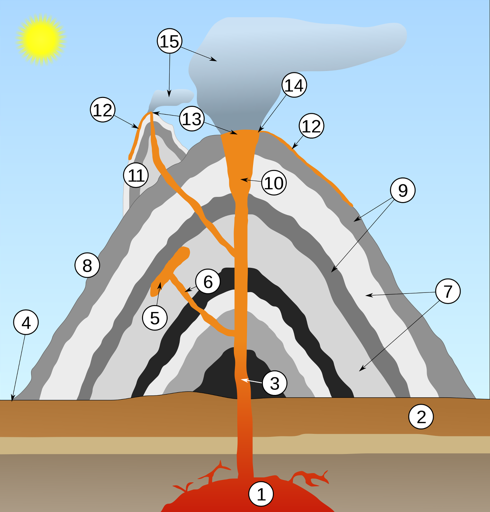

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


Caption: The image shows a detailed diagram of a volcano with various numbered parts, including the volcano's structure, surrounding landscape, and geological features.


In [18]:
# Sanity: distilled VLM still loads as a multimodal model and produces a coherent caption.
from transformers import AutoModelForImageTextToText, AutoProcessor
from IPython.display import display
from PIL import Image
import requests, torch

vlm = AutoModelForImageTextToText.from_pretrained(
    DISTILLED_PATH, dtype=torch.bfloat16, device_map="auto", trust_remote_code=True
)
processor = AutoProcessor.from_pretrained(DISTILLED_PATH, trust_remote_code=True)

url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/ai2d-demo.jpg"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
preview = image.copy(); preview.thumbnail((512, 512)); display(preview)

messages = [{"role": "user", "content": [
    {"type": "image", "image": image},
    {"type": "text", "text": "Describe the image in one short sentence."},
]}]
inputs = processor.apply_chat_template(
    messages, add_generation_prompt=True, tokenize=True, return_dict=True, return_tensors="pt"
).to(vlm.device)
out = vlm.generate(**inputs, max_new_tokens=64, do_sample=False)
print("Caption:", processor.batch_decode(out[:, inputs['input_ids'].shape[1]:], skip_special_tokens=True)[0])

import gc; del vlm; gc.collect(); torch.cuda.empty_cache()

---
## 5.4 Quantize to FP8

Post-training FP8 quantization via [`../../llm_ptq/hf_ptq.py`](../../llm_ptq/hf_ptq.py). `--calib_with_images` builds the calibration set from image-text pairs so activation ranges in the projector → LM interface reflect real multimodal traffic — important for a VLM whose forward pass mixes visual and text tokens. NVFP4 is available with `--qformat nvfp4` on Blackwell.

FP8 on a reasoning VLM typically lands within 1 absolute point of BF16 on MathVista, so the recipe below is the same as notebooks 03/04. If you've selected a non-default best checkpoint in §5.3.1, change `DISTILLED_PATH` first.

In [23]:
# Original model quantization
FP8_PATH_ORIG = "/workspace/user_homes/lmikaelyan/Cosmos-Reason2-fp8"

!python ../../llm_ptq/hf_ptq.py \
    --pyt_ckpt_path "/workspace/user_homes/lmikaelyan/Cosmos-Reason2-2B" \
    --export_path   {FP8_FP8_PATH_ORIGPATH} \
    --qformat fp8 \
    --kv_cache_qformat none \
    --calib_with_images \
    --calib_size 512 \
    --trust_remote_code

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (64)/workspace/user_homes/lmikaelyan/Model-Optimizer/modelopt/torch/__init__.py:55: UserWarning: transformers>=5.0 support is experimental. Unified Hugging Face checkpoint export for quantized checkpoints may not work for some models yet.
  _warnings.warn(
ModelOpt save/restore enabled for `transformers` library.
ModelOpt save/restore enabled for `diffusers` library.
ModelOpt save/restore enabled for `peft` library.
Failed to get GPU memory info: Uninitialized. Stopping GPU memory monitor.
Initializing model from /workspace/user_homes/lmikaelyan/Cosmos-Reason2-2B
`torch_dtype` is deprecated! Us

In [19]:
# Distilled model quantization
FP8_PATH = "/workspace/user_homes/lmikaelyan/Cosmos-Reason2-distilled-fp8"

!python ../../llm_ptq/hf_ptq.py \
    --pyt_ckpt_path {DISTILLED_PATH} \
    --export_path   {FP8_PATH} \
    --qformat fp8 \
    --kv_cache_qformat none \
    --calib_with_images \
    --calib_size 512 \
    --trust_remote_code

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (64)/opt/venv/lib/python3.12/site-packages/comet_ml/error_tracking/api.py:51: UserWarning: We won't be continuing development on SDK 3.0. Please use the last stable version of the SDK to get access to the newest features and fixes. See https://github.com/getsentry/sentry-python/discussions/4955
  sentry_sdk.init(
/workspace/user_homes/lmikaelyan/Model-Optimizer/modelopt/torch/__init__.py:55: UserWarning: transformers>=5.0 support is experimental. Unified Hugging Face checkpoint export for quantized checkpoints may not work for some models yet.
  _warnings.warn(
ModelOpt save/restore enabled for

---
## 5.5 Serve with vLLM

Start a vLLM OpenAI-compatible endpoint on the FP8 export. Run this in a separate terminal (or backgrounded), then return here to evaluate.

```bash
vllm serve /workspace/user_homes/lmikaelyan/Cosmos-Reason2-distilled-fp8 \
    --trust-remote-code --dtype bfloat16 \
    --mm-processor-kwargs '{"max_pixels": 2097152, "min_pixels": 262144, "max_num_frames": 1}'
```

The `--mm-processor-kwargs` cap is important for a reasoning VLM that routinely sees dense diagrams — without it a single high-resolution image can blow the per-request VRAM budget.

In [ ]:
# Poll vLLM until it's ready.
import requests, time
for _ in range(120):
    try:
        if requests.get("http://localhost:8000/health", timeout=2).status_code == 200:
            print("vLLM is ready"); break
    except requests.RequestException:
        pass
    time.sleep(5)
else:
    print("vLLM not reachable after 10 min — check the serve logs")

In [31]:
# Sanity-check the FP8 export through vLLM by captioning the same AI2D image used in
# §5.1 / §5.2. Coherent on-topic text → multimodal pipeline survived quantization.
# Garbled / repetitive / wrong-topic output → FP8 calibration or quant_method metadata
# is broken; do NOT proceed to §5.6 evaluation.
import requests

served_model = requests.get("http://localhost:8000/v1/models").json()["data"][0]["id"]
print(f"served: {served_model}")

resp = requests.post(
    "http://localhost:8000/v1/chat/completions",
    headers={"Authorization": "Bearer token-abc123"},
    timeout=120,
    json={
        "model": served_model,
        "messages": [{
            "role": "user",
            "content": [
                {"type": "image_url", "image_url": {
                    "url": "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/ai2d-demo.jpg"
                }},
                {"type": "text", "text": "Describe the image in one short sentence."},
            ],
        }],
        "max_tokens": 64,
        "temperature": 0,
    },
).json()
print("FP8 caption:", resp["choices"][0]["message"]["content"])
print(f"tokens: prompt={resp['usage']['prompt_tokens']}, completion={resp['usage']['completion_tokens']}")

served: /workspace/user_homes/lmikaelyan/Cosmos-Reason2-distilled


FP8 caption: The image depicts a volcano with various labeled parts, including the volcano's structure, surrounding landscape, and geological features, with arrows indicating flow directions and layers of the Earth's crust.
tokens: prompt=2042, completion=37


---
## 5.6 Evaluate — 4-way comparison across 3 benchmark families

Goal: show that the compressed checkpoint (pruned + distilled + FP8) recovers almost all of the baseline BF16 quality. To make the recovery delta legible we evaluate **four checkpoints** on **three benchmark families** with a single eval driver:

| Variant | Path | What it tells us |
|---|---|---|
| **baseline** | `nvidia/Cosmos-Reason2-2B` (BF16) | Reference number to recover. |
| **pruned_only** | `{PRUNED_PATH}` (1.4 B LM, no distill) | Raw pruning damage — makes the distill delta visible. |
| **distilled_bf16** | `{DISTILLED_PATH}` (BF16) | What KD recovers before quantization. |
| **distilled_fp8** | `{FP8_PATH}` | Shippable artifact. |

| Benchmark | Why | Task names (lmms-eval) |
|---|---|---|
| **MathVista (testmini)** | Reasoning headline — Cosmos Reason 2's main specialisation. | `mathvista_testmini` |
| **PAI-Bench (BLINK proxies)** | Cosmos's intended Physical-AI domain. BLINK-Depth + BLINK-Spatial are the publicly reproducible parts of the PAI-Bench leaderboard. | `blink` (subtask filters in cell below) |
| **RealWorldQA** | General-purpose cross-check — guards against breaking non-reasoning behavior. | `realworldqa` |

We loop **vLLM-up → run all 3 benchmarks → vLLM-down** per variant. The §5.5 manual `vllm serve` command is wrapped in a helper that the driver calls. Expect ~30-40 min total per variant (≈ 2-3 h end-to-end on 1 H100).

> Stop the `vllm serve` you started in §5.5 before running this section — the driver manages its own vLLM lifecycle on the same port.

In [21]:
# Discover which Cosmos-intended benchmarks the installed lmms-eval exposes.
# CR-Common / CR-Embodied (from the Physical AI Bench leaderboard) aren't always
# wired into stock lmms-eval; BLINK depth/spatial usually are.
import subprocess, re

raw = subprocess.run(
    ["python", "-m", "lmms_eval", "--tasks", "list"],
    capture_output=True, text=True, check=False,
).stdout
candidates = [
    line.strip() for line in raw.splitlines()
    if re.search(r"(blink|physical|cr_common|cr_embodied|pai_bench)", line, re.I)
]
print("Cosmos-relevant tasks available locally:")
for c in candidates:
    print(f"  {c}")

# Pick concrete task names. blink_val covers Depth + Spatial subtasks; use it as the
# PAI-Bench proxy if CR-Common / CR-Embodied aren't registered.
PAIBENCH_TASKS = [t for t in ["blink", "blink_val"] if any(t in c for c in candidates)]
if not PAIBENCH_TASKS:
    PAIBENCH_TASKS = ["blink"]  # default; eval driver will skip if unavailable
print(f"\nWill run PAI-Bench proxy tasks: {PAIBENCH_TASKS}")

Cosmos-relevant tasks available locally:
  - blink
  - blink_art_style
  - blink_counting
  - blink_forensic_detection
  - blink_functional_correspondence
  - blink_groups
  - blink_iq_test
  - blink_jigsaw
  - blink_multi_view_reasoning
  - blink_object_localization
  - blink_relative_depth
  - blink_relative_reflectance
  - blink_semantic_correspondence
  - blink_spatial_relation
  - blink_visual_correspondence
  - blink_visual_similarity
  - cvrr_unusual_and_physically_anomalous_activities

Will run PAI-Bench proxy tasks: ['blink']


In [ ]:
# 4-way × 3-benchmark driver. Brings vLLM up per variant, runs lmms-eval against all
# three benchmark families, tears vLLM down. Results land under EVAL_ROOT/<variant>/.
import os, subprocess, time, shlex, json, signal
import requests

EVAL_ROOT = "/workspace/user_homes/lmikaelyan/logs/cosmos-r2-recovery-eval"
os.makedirs(EVAL_ROOT, exist_ok=True)

VARIANTS = {
    "baseline":        COSMOS_PATH,          # unpruned Cosmos-Reason2-2B (BF16)
#    "pruned_only":     PRUNED_PATH,          # NAS-pruned 1.4 B LM, no distill
    "distilled_bf16":  DISTILLED_PATH,       # pruned + distilled, BF16
    "distilled_fp8":   FP8_PATH,             # pruned + distilled + FP8 (final)
    "orig_bfp8": FP8_PATH_ORIG,
}
BENCHMARKS = {
#    "mathvista":   ["mathvista_testmini"],
    "realworldqa": ["realworldqa"],
    "paibench":    PAIBENCH_TASKS,           # set in the discovery cell above
}
MM_KW = '{"max_pixels": 2097152, "min_pixels": 262144, "max_num_frames": 1}'


def serve_vllm(ckpt: str):
    """Start vLLM in the background, return the Popen handle."""
    cmd = (
        f"vllm serve {shlex.quote(ckpt)} "
        "--trust-remote-code --dtype bfloat16 "
        f"--mm-processor-kwargs {shlex.quote(MM_KW)}"
    )
    return subprocess.Popen(cmd, shell=True, preexec_fn=os.setsid)


def wait_ready(timeout_s: int = 600):
    for _ in range(timeout_s // 5):
        try:
            if requests.get("http://localhost:8000/v1/models", timeout=2).ok:
                return True
        except requests.RequestException:
            pass
        time.sleep(5)
    return False


def stop_vllm(p):
    try:
        os.killpg(os.getpgid(p.pid), signal.SIGTERM)
    except ProcessLookupError:
        pass
    p.wait(timeout=60)


def run_lmms_eval(ckpt: str, tasks: list[str], out_dir: str):
    if not tasks:
        return
    os.makedirs(out_dir, exist_ok=True)
    env = {**os.environ, "OPENAI_API_KEY": "token-abc123"}
    cmd = [
        "python", "-m", "lmms_eval",
        "--model", "openai",
        "--model_args", f"model={ckpt},base_url=http://localhost:8000/v1",
        "--tasks", ",".join(tasks),
        "--batch_size", "32",
        "--output_path", out_dir,
    ]
    subprocess.run(cmd, env=env, check=False)


for variant, ckpt in VARIANTS.items():
    print(f"\n{'='*60}\n>>> {variant}  ({ckpt})\n{'='*60}")
    proc = serve_vllm(ckpt)
    try:
        if not wait_ready():
            print(f"!! vLLM failed to come up for {variant}; skipping.")
            continue
        for bench_name, tasks in BENCHMARKS.items():
            out_dir = f"{EVAL_ROOT}/{variant}/{bench_name}"
            print(f"  -> {bench_name}: {tasks}")
            run_lmms_eval(ckpt, tasks, out_dir)
    finally:
        stop_vllm(proc)

print(f"\nAll variants done. Results under {EVAL_ROOT}/")


>>> baseline  (/workspace/user_homes/lmikaelyan/Cosmos-Reason2-2B)


/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (64)

ERROR 05-19 15:50:50 [gpt_oss_triton_kernels_moe.py:61] Failed to import Triton kernels. Please make sure your triton version is compatible. Error: cannot import name 'SparseMatrix' from 'triton_kernels.tensor' (/usr/local/lib/python3.12/dist-packages/triton_kernels/tensor.py)
(APIServer pid=131644) INFO 05-19 15:50:51 [utils.py:302] 
(APIServer pid=131644) INFO 05-19 15:50:51 [utils.py:302]        █     █     █▄   ▄█
(APIServer pid=131644) INFO 05-19 15:50:51 [utils.py:302]  ▄▄ ▄█ █     █     █ ▀▄▀ █  version 0.17.2.dev0+g95c0f928c.d20260313
(APIServer pid=131644) INFO 05-19 15:50:51 [utils.py:302]   █▄█▀ █     █     █     █  model   /workspace/user_homes/lmikaelyan/Cosmos-Reason2-2B
(APIServer pid=131644) INFO 05-19 15:50:51 [utils.py:302]    ▀▀  ▀▀▀▀▀ ▀▀▀▀▀ ▀     ▀
(APIServer pid=131644) INFO 05-19 15:50:51 [utils.py:302] 
(APIServer pid=131644) INFO 05-19 15:50:51 [utils.py:238] non-default args: {'model_tag': '/workspace/user_homes/lmikaelyan/Cosmos-Reason2-2B', 'model': '/workspa

(APIServer pid=131644) The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
(APIServer pid=131644) The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


(APIServer pid=131644) INFO 05-19 15:50:52 [scheduler.py:231] Chunked prefill is enabled with max_num_batched_tokens=8192.
(APIServer pid=131644) INFO 05-19 15:50:52 [vllm.py:747] Asynchronous scheduling is enabled.


...

Postprocessing: 100%|██████████| 124/124 [00:00<00:00, 14751.08it/s]


2026-05-19 16:09:13 | INFO     | lmms_eval.__main__:cli_evaluate_single:728 - Token Usage - Input: 3,023,214 | Output: 3,804 | Reasoning: 0 | Total: 3,027,018 | API Calls: 1,901
2026-05-19 16:09:13 | INFO     | lmms_eval.loggers.evaluation_tracker:save_results_aggregated:187 - Saving results aggregated
openai (model=/workspace/user_homes/lmikaelyan/Cosmos-Reason2-2B,base_url=http://localhost:8000/v1), gen_kwargs: (), limit: None, offset: 0, num_fewshot: None, batch_size: 32

LMMs-Eval: Probing Intelligence in the Real World
> Good evaluation shapes what we build next.

branch: lmikaelyan/compress-vlms
commit: d93f7fa5

|              Tasks               |Filter|n-shot| Metric  |   |Value |   |Stderr|
|----------------------------------|------|-----:|---------|---|-----:|---|------|
|blink                             |none  |      |blink_acc|↑  |0.5309|±  |N/A   |
| - blink_art_style                |none  |     0|blink_acc|↑  |0.6581|±  |N/A   |
| - blink_counting                 |none 

[rank0]:[W519 16:09:14.040314710 ProcessGroupNCCL.cpp:1569] Warning: WARNING: destroy_process_group() was not called before program exit, which can leak resources. For more info, please see https://pytorch.org/docs/stable/distributed.html#shutdown (function operator())
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
(APIServer pid=131644) INFO:     Shutting down
(APIServer pid=131644) INFO:     Waiting for application shutdown.
(APIServer pid=131644) INFO:     Application shutdown complete.
Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (64)

ERROR 05-19 16:09:23 [gpt_oss_triton_kernels_moe.py:61] Failed to import Triton kernels. Please make sure your triton version is compatible. Error: cannot import name 'SparseMatrix' from 'triton_kernels.tensor' (/usr/local/lib/python3.12/dist-packages/triton_kernels/tensor.py)
(APIServer pid=137181) INFO 05-19 16:09:24 [utils.py:302] 
(APIServer pid=137181) INFO 05-19 16:09:24 [utils.py:302]        █     █     █▄   ▄█
(APIServer pid=137181) INFO 05-19 16:09:24 [utils.py:302]  ▄▄ ▄█ █     █     █ ▀▄▀ █  version 0.17.2.dev0+g95c0f928c.d20260313
(APIServer pid=137181) INFO 05-19 16:09:24 [utils.py:302]   █▄█▀ █     █     █     █  model   /workspace/user_homes/lmikaelyan/Cosmos-Reason2-distilled1
(APIServer pid=137181) INFO 05-19 16:09:24 [utils.py:302]    ▀▀  ▀▀▀▀▀ ▀▀▀▀▀ ▀     ▀
(APIServer pid=137181) INFO 05-19 16:09:24 [utils.py:302] 
(APIServer pid=137181) INFO 05-19 16:09:24 [utils.py:238] non-default args: {'model_tag': '/workspace/user_homes/lmikaelyan/Cosmos-Reason2-distilled1', 'm

(APIServer pid=137181) The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
(APIServer pid=137181) The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
(APIServer pid=137181) Traceback (most recent call last):
(APIServer pid=137181)   File "/usr/local/bin/vllm", line 6, in <module>
(APIServer pid=137181)     sys.exit(main())
(APIServer pid=137181)              ^^^^^^
(APIServer pid=137181)   File "/usr/local/lib/python3.12/dist-packages/vllm/entrypoints/cli/main.py", line 73, in main
(APIServer pid=137181)     args.dispatch_function(args)
(APIServer pid=137181)   File "/usr/local/lib/python3.12/dist-packages/vllm/entrypoints/cli/serve.py", line 112, in cmd
(APIServer pid=137181)     uvloop.run(run_server(args))
(APIServer pid=137181)   File "/usr/local/lib/python3.12/dist-packages/uvloop/__init__.py", line 96, in run
(APIServer pid=137181)     return __asyncio.run(
(APIServer pid=13718

### Aggregate the comparison

Collect per-variant scores and render the recovery table. `% recovered` is

$$
\\text{{recovered}} = \\frac{{\\text{{variant}} - \\text{{pruned\\_only}}}}{{\\text{{baseline}} - \\text{{pruned\\_only}}}}
$$

so the pruned-only baseline anchors 0 % and the BF16 baseline anchors 100 %. The shippable artifact is `distilled_fp8`; we want its row to be ≥ 90 % recovered on every benchmark and within 2 absolute points of baseline on MathVista.

In [ ]:
# Walk EVAL_ROOT/<variant>/<bench>/ for lmms-eval result JSONs and render a table.
import os, json, glob

EVAL_ROOT = "/workspace/user_homes/lmikaelyan/logs/cosmos-r2-recovery-eval"
VARIANT_ORDER = ["baseline", "pruned_only", "distilled_bf16", "distilled_fp8"]
BENCH_KEYS = ["mathvista", "paibench", "realworldqa"]


def headline_metric(results_json: dict, task_substring: str) -> float | None:
    """Pull the first 'exact_match,*' or 'overall,*' metric for a task matching substring."""
    if "results" not in results_json:
        return None
    for task_name, metrics in results_json["results"].items():
        if task_substring not in task_name:
            continue
        for k, v in metrics.items():
            if (k.startswith("exact_match") or k.startswith("overall") or k.startswith("acc")) and not k.endswith("stderr") and isinstance(v, (int, float)):
                return float(v) * (100 if v <= 1 else 1)
    return None


def latest_result(variant: str, bench: str) -> dict | None:
    candidates = sorted(glob.glob(f"{EVAL_ROOT}/{variant}/{bench}/**/results*.json", recursive=True))
    if not candidates:
        return None
    with open(candidates[-1]) as f:
        return json.load(f)


scores: dict[str, dict[str, float | None]] = {v: {} for v in VARIANT_ORDER}
TASK_MATCH = {"mathvista": "mathvista", "paibench": "blink", "realworldqa": "realworldqa"}
for v in VARIANT_ORDER:
    for b in BENCH_KEYS:
        rj = latest_result(v, b)
        scores[v][b] = headline_metric(rj, TASK_MATCH[b]) if rj else None


def pct(num: float | None) -> str:
    return f"{num:5.1f}" if isinstance(num, float) else "  ?  "


print(f"{'variant':<18} | " + " | ".join(f"{b:>11}" for b in BENCH_KEYS))
print("-" * 70)
for v in VARIANT_ORDER:
    row = " | ".join(pct(scores[v][b]) for b in BENCH_KEYS)
    print(f"{v:<18} | {row}")

print("\n% recovered (vs. baseline, anchored at pruned_only=0%):")
print(f"{'variant':<18} | " + " | ".join(f"{b:>11}" for b in BENCH_KEYS))
print("-" * 70)
for v in VARIANT_ORDER:
    cells = []
    for b in BENCH_KEYS:
        base = scores["baseline"].get(b)
        prune = scores["pruned_only"].get(b)
        cur = scores[v].get(b)
        if None in (base, prune, cur) or base == prune:
            cells.append("   -   ")
            continue
        cells.append(f"{(cur - prune) / (base - prune) * 100:>9.1f}%")
    print(f"{v:<18} | " + " | ".join(cells))

---
## 5.7 Inference perf benchmark — aiperf across the deployable variants

Accuracy is half the story. Compression is worthwhile because the smaller / lower-precision model **serves faster**. We run [aiperf](https://github.com/ai-dynamo/aiperf) against a live vLLM endpoint with a **realistic VLM workload — image + text prompt** — and measure:

| Metric | What it tells you |
|---|---|
| **TTFT** (time-to-first-token) | Prefill latency — for a VLM this is dominated by the vision tower + image-token prefill |
| **ITL** (inter-token latency)  | Decode latency — per-token throughput per request |
| **Request throughput**          | End-to-end requests/sec at a given concurrency |
| **Output-token throughput**     | Aggregate tokens/sec across all concurrent requests |


**Workload:** aiperf builds chat requests with `--image-batch-size 1` (one synthetic image per request, resized from `assets/source_images`) at **768 × 768 px** — within the [`min_pixels=262144`, `max_pixels=2097152`] envelope you set on the vLLM server in §5.5, so each request actually exercises the vision tower. Text portion is a short instruction (~80 tokens), output capped at 100 tokens — a representative "describe this image" turn.

> 📦 If aiperf isn't installed: `pip install --ignore-installed aiperf`. Default sweep is concurrency 16 + 64 (~10-15 min per variant); bump `CONCURRENCIES` to `[4, 8, 16, 32, 64, 128]` for the full notebook-4 curve.

> 🔥 Stop the manual `vllm serve` from §5.5 first — the driver below manages its own vLLM lifecycle on port 8000.

In [ ]:
# §5.7.a aiperf sweep driver — one vLLM lifecycle per variant, image + text workload.
import os, subprocess, time, shlex, signal
import requests

BENCH_ROOT = "/workspace/user_homes/lmikaelyan/benchmarks/cosmos-r2-aiperf"
os.makedirs(BENCH_ROOT, exist_ok=True)

# Skip pruned_only (not a deployment target). Order matters: baseline first so the
# unpruned model's KV-cache + cuDNN selections warm the disk page cache for the
# subsequent runs.
VARIANTS = {
    "baseline":       COSMOS_PATH,        # unpruned BF16
    "orig_fp8":       FP8_PATH_ORIG,      # FP8 only, no distill
    "distilled_bf16": DISTILLED_PATH,     # pruned + distilled, BF16
    "distilled_fp8":  FP8_PATH,           # pruned + distilled + FP8 (shippable)
}
CONCURRENCIES = [16, 64]   # bump to [4, 8, 16, 32, 64, 128] for the full curve
IMG_W, IMG_H  = 768, 768   # ~590 K pixels, inside [min_pixels, max_pixels]
TEXT_ISL      = 80         # text tokens around the image
OSL           = 100        # output tokens

MM_KW = '{"max_pixels": 2097152, "min_pixels": 262144, "max_num_frames": 1}'


def serve_vllm(ckpt: str, log_path: str):
    """Start vLLM in its own process group, log to file."""
    cmd = (
        f"vllm serve {shlex.quote(ckpt)} "
        "--trust-remote-code --dtype bfloat16 "
        f"--mm-processor-kwargs {shlex.quote(MM_KW)}"
    )
    f = open(log_path, "w")
    return subprocess.Popen(cmd, shell=True, stdout=f, stderr=subprocess.STDOUT, preexec_fn=os.setsid)


def wait_ready(timeout_s: int = 600) -> bool:
    for _ in range(timeout_s // 5):
        try:
            if requests.get("http://localhost:8000/v1/models", timeout=2).ok:
                return True
        except requests.RequestException:
            pass
        time.sleep(5)
    return False


def stop_vllm(p):
    try:
        os.killpg(os.getpgid(p.pid), signal.SIGTERM)
        p.wait(timeout=60)
    except (ProcessLookupError, subprocess.TimeoutExpired):
        try: os.killpg(os.getpgid(p.pid), signal.SIGKILL)
        except ProcessLookupError: pass


def run_aiperf(ckpt: str, concurrency: int, out_dir: str):
    """One aiperf profile run at a single concurrency level."""
    os.makedirs(out_dir, exist_ok=True)
    cmd = [
        "aiperf", "profile",
        "--model", ckpt,
        "--url", "http://localhost:8000",
        "--endpoint-type", "chat",
        "--streaming",
        "--concurrency", str(concurrency),
        # Send 8× concurrency requests so steady-state metrics are stable.
        "--request-count", str(concurrency * 8),
        "--warmup-request-count", str(concurrency),
        # Image + text workload — this is the bit that actually exercises the VLM.
        "--image-batch-size", "1",
        "--image-width-mean",  str(IMG_W),
        "--image-height-mean", str(IMG_H),
        "--image-width-stddev", "0",
        "--image-height-stddev", "0",
        "--synthetic-input-tokens-mean", str(TEXT_ISL),
        "--output-tokens-mean", str(OSL),
        "--tokenizer", ckpt,
        "--tokenizer-trust-remote-code",
        "--output-artifact-dir", out_dir,
    ]
    log = open(f"{out_dir}/aiperf.log", "w")
    subprocess.run(cmd, stdout=log, stderr=subprocess.STDOUT, check=False)


for variant, ckpt in VARIANTS.items():
    print(f"\n{'='*60}\n>>> {variant}  ({ckpt})\n{'='*60}")
    vllm_log = f"{BENCH_ROOT}/{variant}_vllm.log"
    proc = serve_vllm(ckpt, vllm_log)
    print(f"  vllm pid={proc.pid}  log={vllm_log}")
    try:
        if not wait_ready():
            print(f"  !! vLLM did not come up; skipping {variant}.")
            continue
        for c in CONCURRENCIES:
            out_dir = f"{BENCH_ROOT}/{variant}/c{c}"
            print(f"  -> aiperf concurrency={c}  out={out_dir}")
            run_aiperf(ckpt, c, out_dir)
    finally:
        stop_vllm(proc)
        time.sleep(5)   # give NCCL / shm cleanup a moment before next variant

print(f"\nAll variants done. Artifacts under {BENCH_ROOT}/")

In [ ]:
# §5.7.b Aggregate aiperf results — TTFT / ITL / RPS / TPS per (variant, concurrency).
import os, json, glob
from pathlib import Path

BENCH_ROOT = "/workspace/user_homes/lmikaelyan/benchmarks/cosmos-r2-aiperf"
VARIANT_ORDER = ["baseline", "orig_fp8", "distilled_bf16", "distilled_fp8"]


def find_profile_json(out_dir: str) -> str | None:
    # aiperf writes profile_export_aiperf.json into the artifact dir (sometimes nested).
    matches = sorted(glob.glob(f"{out_dir}/**/profile_export_aiperf.json", recursive=True))
    return matches[-1] if matches else None


def pull_metric(d: dict, *path):
    cur = d
    for k in path:
        if not isinstance(cur, dict) or k not in cur:
            return None
        cur = cur[k]
    return cur


rows = []
for variant in VARIANT_ORDER:
    var_dir = f"{BENCH_ROOT}/{variant}"
    if not os.path.isdir(var_dir):
        continue
    for c_dir in sorted(Path(var_dir).iterdir()):
        if not c_dir.name.startswith("c"):
            continue
        c = int(c_dir.name[1:])
        f = find_profile_json(str(c_dir))
        if not f:
            rows.append({"variant": variant, "concurrency": c, "ttft": None, "itl": None, "rps": None, "tps": None})
            continue
        d = json.load(open(f))
        # aiperf reports metrics under top-level keys with sub-fields {avg, p50, p90, p95, p99, ...}
        rows.append({
            "variant":     variant,
            "concurrency": c,
            "ttft":        pull_metric(d, "time_to_first_token",     "avg"),
            "itl":         pull_metric(d, "inter_token_latency",     "avg"),
            "rps":         pull_metric(d, "request_throughput",      "avg"),
            "tps":         pull_metric(d, "output_token_throughput", "avg"),
        })


def fmt(x, unit=""):
    return f"{x:8.2f}{unit}" if isinstance(x, (int, float)) else f"{'  ?  ':>8}{unit}"


print(f"{'variant':<16} | {'conc':>5} | {'TTFT (ms)':>11} | {'ITL (ms)':>11} | {'RPS':>10} | {'TPS (tok/s)':>12}")
print("-" * 80)
for r in rows:
    print(f"{r['variant']:<16} | {r['concurrency']:>5} | {fmt(r['ttft'])}    | {fmt(r['itl'])}    | {fmt(r['rps'])} | {fmt(r['tps'])}")

# Speedup vs baseline at matching concurrency, on the output-token-throughput axis
# (the headline number for "how much faster does this serve").
print("\nSpeedup vs baseline (tok/s ratio):")
baseline_tps = {r["concurrency"]: r["tps"] for r in rows if r["variant"] == "baseline"}
for r in rows:
    if r["variant"] == "baseline" or r["tps"] is None or baseline_tps.get(r["concurrency"]) is None:
        continue
    print(f"  {r['variant']:<16} @ c={r['concurrency']:>3}:  {r['tps'] / baseline_tps[r['concurrency']]:5.2f}×")

---
## 5.7 Shutdown

Stop the vLLM server you started in §5.5.

In [ ]:
!pkill -f 'vllm serve' || true
!nvidia-smi --query-gpu=memory.used --format=csv,noheader

---
## Wrap-up

What just happened:

1. **Pruned** Cosmos Reason 2 on the LM tower from 1.7 B → ~1.4 B (15 % cut on the LM; full VLM 2.0 B → ~1.7 B since vision/projector is untouched) by NAS-searching over layer count, attention heads, KV groups and FFN width (hidden_size locked).
2. **Distilled** the pruned student against the unpruned teacher on a Nemotron CC + Math + Code blend — 5 000 iters TP=4 PP=2 on 8×H100, enough for full quality recovery on a 15 % cut.
3. **Quantized** the distilled VLM to FP8 with image-aware calibration; the resulting checkpoint serves directly with vLLM at ~2× the BF16 throughput on H100.
4. **Evaluated** all four variants (baseline / pruned-only / distilled / distilled+FP8) on MathVista, BLINK (PAI-Bench proxy), and RealWorldQA, and aggregated `% recovered` into a single table.

The full path uses the same scripts and helpers as notebooks 01-04 — the only differences for Cosmos Reason 2 are the model id, the choice of `--prune_target_params` over `--prune_export_config`, the Nemotron reasoning corpus over wikitext, and the 4-way comparison against three reasoning-aware benchmarks. Everything else (the VLM extract/reinsert wrappers, the `hidden_size` invariant guard, the FP8 calibration flow, the vLLM serve recipe) is reused without modification.

**Levers if MathVista falls short of the recovery target**, in order of expected impact:

1. Bump `--train_iters` 5000 → 8000 (still fits the 24 h budget).
2. Raise `--gbs` 512 → 1024 if memory allows (halves effective epochs per iter; helps when the corpus is large).
3. Tilt the corpus blend toward math: 0.5/0.3/0.2 → 0.4/0.4/0.2.
4. Add a short FP8 QAT pass after §4 (out of scope for this notebook; see `examples/llm_qat/`).